In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
DATA_PATH = "../data/irrigation_prediction.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (10000, 20)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [3]:
print("Columns:")
print(df.columns.tolist())  #total list

print("\nData types:")
print(df.dtypes)  # datatype

print("\nDataset information:")
df.info()  #dataset info

print("\nMissing values:")
print(df.isnull().sum())  #missing value


print("\nDuplicate rows:", df.duplicated().sum())  # Duplicate rows

print("\nStatistical summary:")
display(df.describe(include="all").T)  #statistical summary

Columns:
['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

Data types:
Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str
Previous_Irrigation_mm     float64
Region  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Soil_Type,10000,4,Sandy,2536,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Soil_pH,10000.0,NaN,NaN,NaN,6.487857,0.979963,4.8,5.64,6.47,7.35,8.2
Soil_Moisture,10000.0,NaN,NaN,NaN,36.969207,16.430845,8.0,22.86,37.24,50.94,65.0
Organic_Carbon,10000.0,NaN,NaN,NaN,0.944731,0.372406,0.3,0.62,0.95,1.26,1.6
Electrical_Conductivity,10000.0,NaN,NaN,NaN,1.791963,0.984202,0.1,0.94,1.78,2.65,3.5
Temperature_C,10000.0,NaN,NaN,NaN,26.991423,8.664074,12.0,19.46,27.09,34.5,42.0
Humidity,10000.0,NaN,NaN,NaN,60.080339,20.187973,25.0,42.855,60.04,77.705,95.0
Rainfall_mm,10000.0,NaN,NaN,NaN,1252.49942,715.582201,0.38,634.155,1250.335,1880.265,2499.69
Sunlight_Hours,10000.0,NaN,NaN,NaN,7.518538,2.016077,4.0,5.76,7.56,9.26,11.0
Wind_Speed_kmh,10000.0,NaN,NaN,NaN,10.163545,5.670923,0.5,5.16,10.19,15.1,20.0


In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())  #clean column name

['soil_type', 'soil_ph', 'soil_moisture', 'organic_carbon', 'electrical_conductivity', 'temperature_c', 'humidity', 'rainfall_mm', 'sunlight_hours', 'wind_speed_kmh', 'crop_type', 'crop_growth_stage', 'season', 'irrigation_type', 'water_source', 'field_area_hectare', 'mulching_used', 'previous_irrigation_mm', 'region', 'irrigation_need']


In [5]:
print(df["irrigation_need"].value_counts())  #Check the target distribution

irrigation_need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64


In [6]:
target_percent = (
    df["irrigation_need"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percent)   #calculate percentage

irrigation_need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64


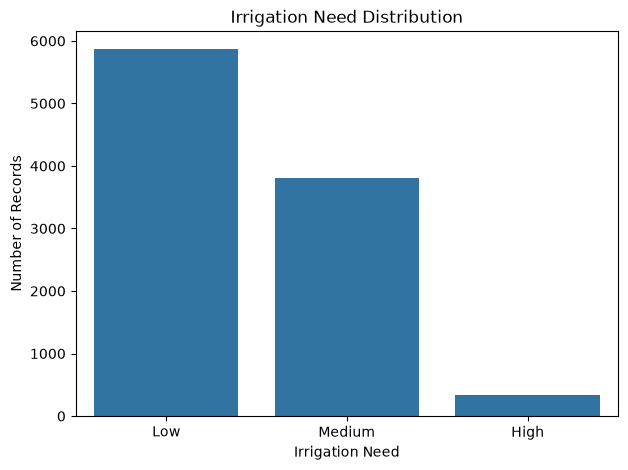

In [7]:
plt.figure(figsize=(7, 5))   #Plot

sns.countplot(
    data=df,
    x="irrigation_need"
)

plt.title("Irrigation Need Distribution")
plt.xlabel("Irrigation Need")
plt.ylabel("Number of Records")

plt.show()

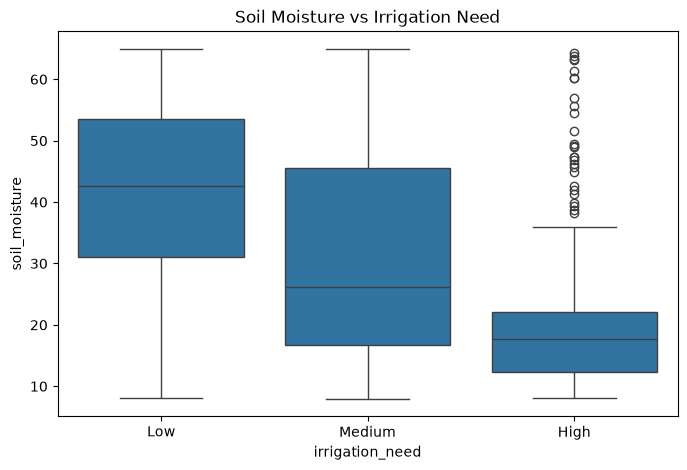

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="irrigation_need",
    y="soil_moisture"
)

plt.title("Soil Moisture vs Irrigation Need")
plt.show()

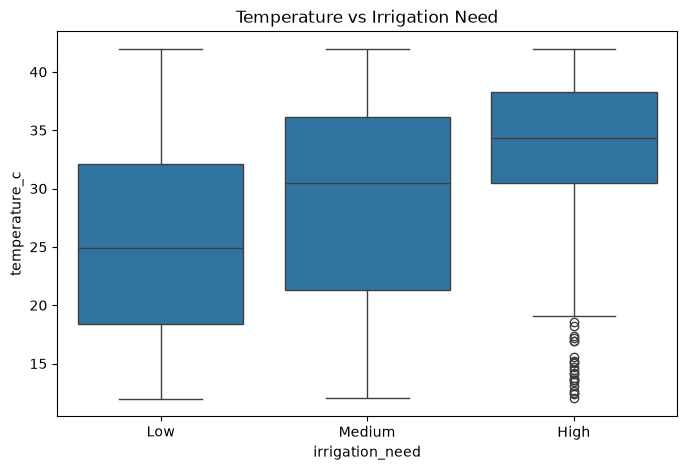

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="irrigation_need",
    y="temperature_c"
)

plt.title("Temperature vs Irrigation Need")
plt.show()

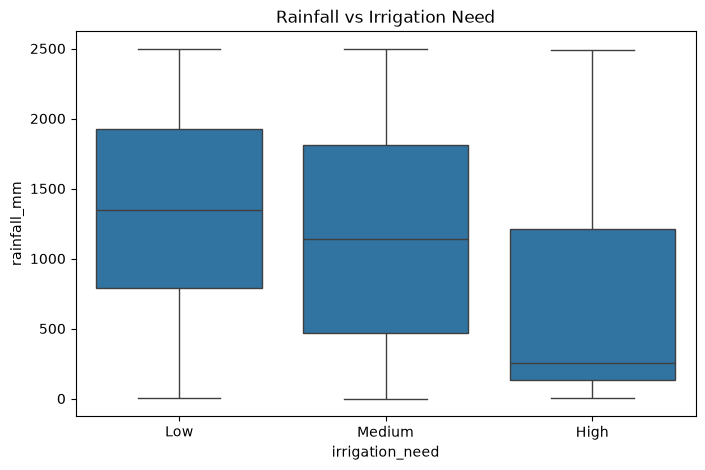

In [10]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="irrigation_need",
    y="rainfall_mm"
)

plt.title("Rainfall vs Irrigation Need")
plt.show()

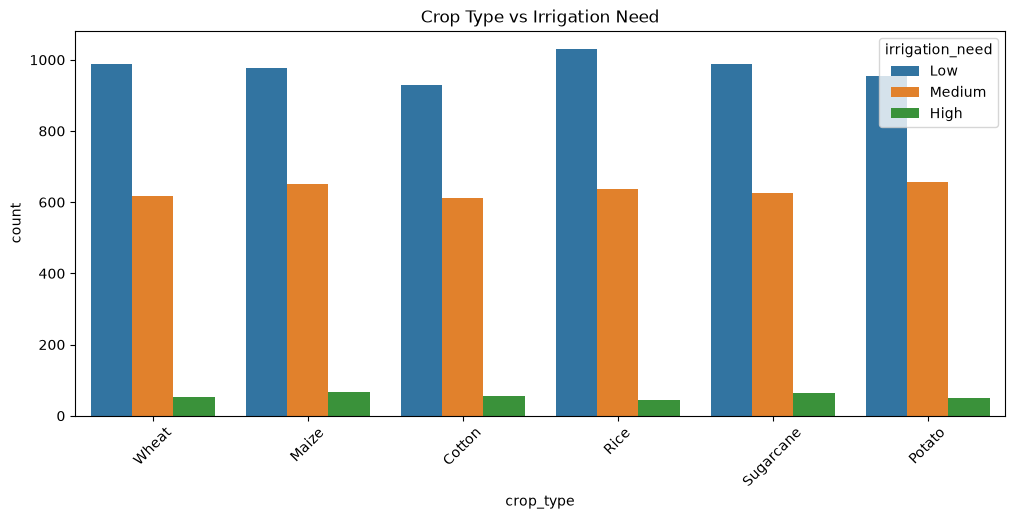

In [11]:
plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x="crop_type",
    hue="irrigation_need"
)

plt.xticks(rotation=45)
plt.title("Crop Type vs Irrigation Need")
plt.show()

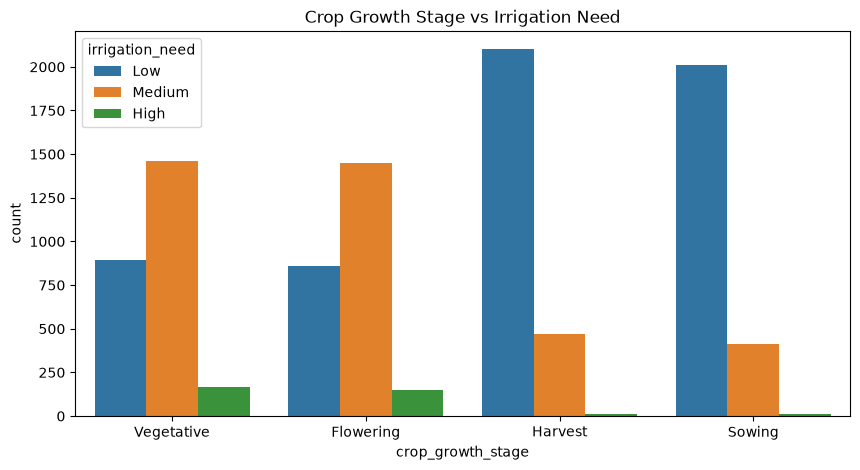

In [12]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="crop_growth_stage",
    hue="irrigation_need"
)

plt.title("Crop Growth Stage vs Irrigation Need")
plt.show()

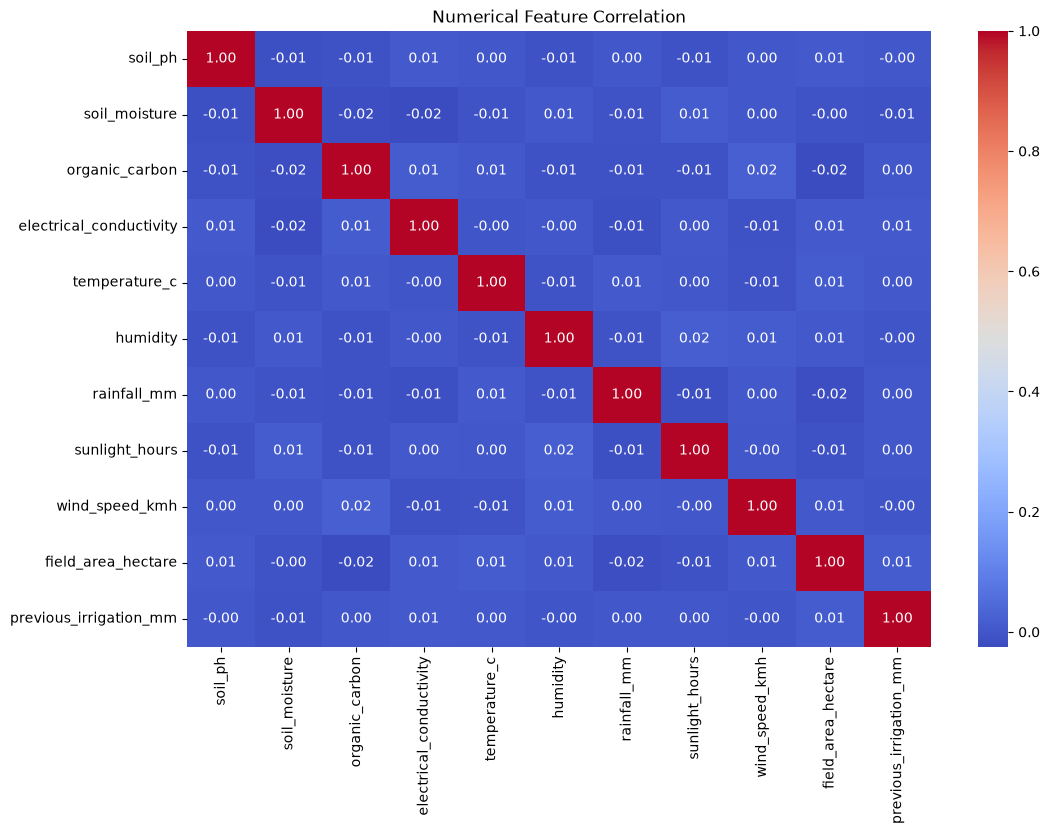

In [13]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")
plt.show()

In [14]:
#Create X and y

X = df.drop(
    columns=[
        "irrigation_need",
        "irrigation_type",
        "water_source"
    ]
)

y = df["irrigation_need"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 17)
Target: (10000,)


In [15]:
#Split the data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 8000
Testing rows : 2000


In [16]:
#Create numerical_features and categorical_features

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['soil_type', 'crop_type', 'crop_growth_stage', 'season', 'mulching_used', 'region']

Numerical features:
['soil_ph', 'soil_moisture', 'organic_carbon', 'electrical_conductivity', 'temperature_c', 'humidity', 'rainfall_mm', 'sunlight_hours', 'wind_speed_kmh', 'field_area_hectare', 'previous_irrigation_mm']


In [17]:
#the preprocessing pipeline


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [18]:
#split your dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 17)
X_test : (2000, 17)
y_train: (8000,)
y_test : (2000,)


In [19]:
#train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Metrics imported successfully!")

Metrics imported successfully!


In [22]:
# Make predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

# Classification report
print("\nRandom Forest Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=["Low", "Medium", "High"],
        digits=4,
        zero_division=0
    )
)

Random Forest Accuracy: 0.987

Random Forest Classification Report
              precision    recall  f1-score   support

         Low     0.9974    0.9991    0.9983      1173
      Medium     0.9705    0.9961    0.9831       760
        High     1.0000    0.6716    0.8036        67

    accuracy                         0.9870      2000
   macro avg     0.9893    0.8889    0.9283      2000
weighted avg     0.9873    0.9870    0.9860      2000



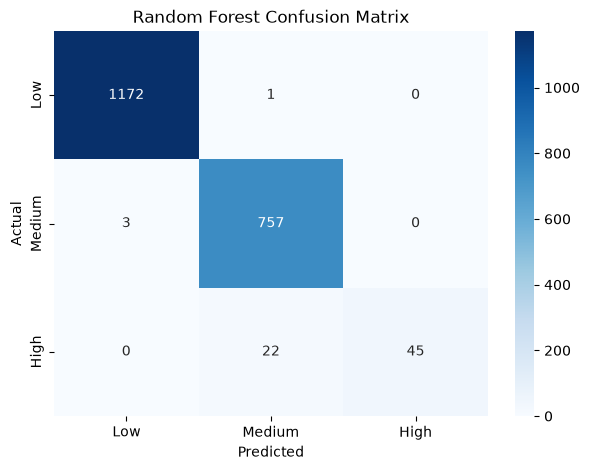

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [24]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['soil_type','soil_ph','soil_moisture',...,'mulching_used', 'previous_irrigation_mm','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [25]:
#Evaluate Random Forest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predictions
rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

# Classification Report
print("\nRandom Forest Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        labels=["Low", "Medium", "High"],
        digits=4,
        zero_division=0
    )
)

Random Forest Accuracy: 0.987

Random Forest Classification Report
              precision    recall  f1-score   support

         Low     0.9974    0.9991    0.9983      1173
      Medium     0.9705    0.9961    0.9831       760
        High     1.0000    0.6716    0.8036        67

    accuracy                         0.9870      2000
   macro avg     0.9893    0.8889    0.9283      2000
weighted avg     0.9873    0.9870    0.9860      2000



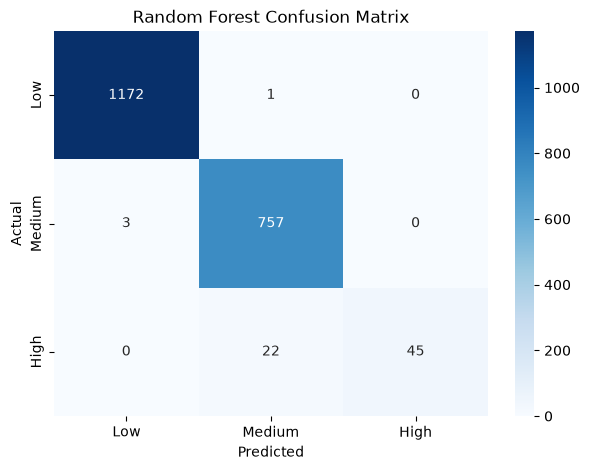

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [27]:
from xgboost import XGBClassifier            #Train XGBoost

# Convert target labels
label_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_encoded = y.map(label_mapping)

# Train/test split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# XGBoost model
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("XGBoost training completed!")

Training XGBoost...
XGBoost training completed!


In [28]:
#Evaluate XGBoost
from sklearn.metrics import accuracy_score, classification_report

xgb_pred = xgb_model.predict(X_test_xgb)

xgb_accuracy = accuracy_score(
    y_test_xgb,
    xgb_pred
)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))

print("\nXGBoost Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_xgb,
        xgb_pred,
        target_names=["Low", "Medium", "High"],
        digits=4,
        zero_division=0
    )
)

XGBoost Accuracy: 0.997

XGBoost Classification Report
              precision    recall  f1-score   support

         Low     0.9991    0.9974    0.9983      1173
      Medium     0.9948    0.9974    0.9961       760
        High     0.9851    0.9851    0.9851        67

    accuracy                         0.9970      2000
   macro avg     0.9930    0.9933    0.9931      2000
weighted avg     0.9970    0.9970    0.9970      2000



In [29]:
#Compare macro F1
from sklearn.metrics import f1_score

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

xgb_f1 = f1_score(
    y_test_xgb,
    xgb_pred,
    average="macro"
)

print("Random Forest Macro F1:", round(rf_f1, 4))
print("XGBoost Macro F1:", round(xgb_f1, 4))

Random Forest Macro F1: 0.9283
XGBoost Macro F1: 0.9931


In [30]:
#the XGBoost classification report
from sklearn.metrics import classification_report, accuracy_score

print("XGBoost Accuracy:")
print(round(accuracy_score(y_test_xgb, xgb_pred), 4))

print("\nXGBoost Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test_xgb,
        xgb_pred,
        target_names=["Low", "Medium", "High"],
        digits=4,
        zero_division=0
)
)

XGBoost Accuracy:
0.997

XGBoost Classification Report
              precision    recall  f1-score   support

         Low     0.9991    0.9974    0.9983      1173
      Medium     0.9948    0.9974    0.9961       760
        High     0.9851    0.9851    0.9851        67

    accuracy                         0.9970      2000
   macro avg     0.9930    0.9933    0.9931      2000
weighted avg     0.9970    0.9970    0.9970      2000



In [31]:
#XGBoost as the final model
best_model = xgb_model
best_model_name = "XGBoost"

print("Final Model:", best_model_name)

Final Model: XGBoost


In [32]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/irrigation_need_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/irrigation_need_model.pkl


In [33]:
loaded_model = joblib.load(
    "../models/irrigation_need_model.pkl"
)

predictions = loaded_model.predict(
    X_test.iloc[:10]
)

print("Predictions:")
print(predictions)

Predictions:
[1 1 0 1 1 0 1 0 1 0]


In [34]:
#Convert predictions to actual labels
label_mapping_reverse = {
    0: "Low",
    1: "Medium",
    2: "High"
}

predicted_labels = [
    label_mapping_reverse[int(pred)]
    for pred in predictions
]

print("Predicted irrigation needs:")
print(predicted_labels)

Predicted irrigation needs:
['Medium', 'Medium', 'Low', 'Medium', 'Medium', 'Low', 'Medium', 'Low', 'Medium', 'Low']


In [36]:
# Make the prediction function
def predict_irrigation_need(input_data):
    """
    Predict irrigation need from field data.

    Returns:
        Low / Medium / High
    """

    prediction = loaded_model.predict(input_data)

    label_mapping_reverse = {
        0: "Low",
        1: "Medium",
        2: "High"
    }

    return [
        label_mapping_reverse[int(pred)]
        for pred in prediction
    ]

In [37]:
#test
result = predict_irrigation_need(
    X_test.iloc[:10]
)

print(result)

['Medium', 'Medium', 'Low', 'Medium', 'Medium', 'Low', 'Medium', 'Low', 'Medium', 'Low']
